In [401]:
%%capture --no-stderr
%pip install --upgrade --quiet langchain langchain-community langchain-chroma beautifulsoup4
%pip install -q langchain_google_genai

LANGCHAIN API KEY \
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

In [402]:
import os
os.environ['LANGCHAIN_TRACING_V2']="true"
os.environ['LANGCHAIN_API_KEY']="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"
os.environ['LANGCHAIN_ENDPOINT']="https://api.smith.langchain.com/"
os.environ['LANGSMITH_PROJECT']="RAG_WITH_SKJ"

In [403]:
from google.colab import userdata
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
os.environ['GOOGLE_API_KEY']= GOOGLE_API_KEY

In [404]:
import warnings
warnings.filterwarnings('ignore')


creating chasing for generating tokens


In [405]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
gemini_embiddings=GoogleGenerativeAIEmbeddings(model="models/embedding-001")

connected with LLM

This code is part of a **LangChain application**, typically used to build **LLM (Large Language Model) powered agents**, like document-based question answering systems. Let's go line by line and explain **what each import does** in the context of a LangChain pipeline.

---

## 🔢 Cell \[8]

```python
import bs4
from langchain import hub
```

### ✅ `import bs4`

* **BeautifulSoup (bs4)** is a Python library for parsing HTML and XML documents.
* You use it when scraping web pages or cleaning HTML content.
* **Example use:** Extracting raw text from HTML loaded from a website.

### ✅ `from langchain import hub`

* The **LangChain Hub** is a central place to **fetch prebuilt prompt templates** and chains.
* Useful for reusing community/shared prompt designs.
* Example: `hub.pull("hwchase17/openai-functions-agent")`

---

## 🔢 Cell \[9]

```python
from langchain.chains import create_retrieval_chain
```

### ✅ `create_retrieval_chain`

* Builds a **retrieval-augmented generation (RAG)** chain.
* Combines a **retriever** (e.g., vector search engine like Chroma) with a **language model** to answer questions based on documents.
* Returns a pipeline that looks like:

  > user question → document retriever → documents → LLM → final answer

---

## 🔢 Cell \[10]

```python
from langchain.chains.combine_documents import create_stuff_documents_chain
```

### ✅ `create_stuff_documents_chain`

* A chain that **"stuffs" all retrieved documents into a single prompt** before sending to the LLM.
* Good for small documents; not scalable to large datasets.
* Other options: **map-reduce**, **refine**, etc. (useful for large inputs).

---

## 🔢 Cell \[11]

```python
from langchain_chroma import Chroma
```

### ✅ `Chroma`

* Imports **ChromaDB integration** for vector storage.
* Chroma is a lightweight **open-source vector database** to store embeddings (numerical representations of text).
* Used for similarity search in document retrieval.

---

## 🔢 Cell \[12]

```python
from langchain_community.document_loaders import WebBaseLoader
```

### ✅ `WebBaseLoader`

* Loads text content directly from a **web URL**.
* Automatically extracts readable content from a webpage.
* Can be used with `bs4` to clean up or further process HTML.

### ⚠️ Warning Below

```text
WARNING: langchain_community.utils.user_agent: USER_AGENT environment variable not set
```

* Some websites block requests without a `User-Agent` header.
* You can fix this by setting an environment variable:

  ```bash
  export USER_AGENT="Mozilla/5.0 ..."
  ```

---

## 🔢 Cell \[13]

```python
from langchain_core.prompts import ChatPromptTemplate
```

### ✅ `ChatPromptTemplate`

* A way to structure multi-turn or dynamic prompts for **chat-based models** (like OpenAI's GPT-4).
* Lets you define roles like:

  ```text
  system: "You are a helpful assistant."
  user: "{question}"
  ```

---

## 🔢 Cell \[14]

```python
from langchain_text_splitters import RecursiveCharacterTextSplitter
```

### ✅ `RecursiveCharacterTextSplitter`

* Splits large documents into smaller chunks for processing.
* Preserves **semantic structure** (splits on paragraph → sentence → character).
* Used before embedding documents for storage in Chroma.

---

## 🔢 Cell \[15]

```python
from langchain_core.prompts import MessagesPlaceholder
```

### ✅ `MessagesPlaceholder`

* Used in dynamic prompt templates.
* Acts as a **placeholder for a list of messages**, usually for maintaining chat history in agents.

---

## 🧩 Summary: What’s Being Built?

This setup is likely for a **web-document-based RAG pipeline**, which does the following:

1. **Load documents** from the web using `WebBaseLoader`.
2. **Clean/process HTML** using `bs4`.
3. **Split text** into chunks with `RecursiveCharacterTextSplitter`.
4. **Store chunks** in a vector DB (`Chroma`) using embeddings.
5. **Build a prompt** using `ChatPromptTemplate`.
6. **Retrieve relevant chunks** and pass to the LLM via `create_retrieval_chain`.
7. Use `MessagesPlaceholder` for memory in chat apps.

---

Would you like a diagram or code example showing how to chain these together?


In [406]:
from langchain_google_genai import ChatGoogleGenerativeAI
model=ChatGoogleGenerativeAI(model="gemini-1.5-flash",convert_system_message_to_human=True)

In [407]:
print(model.invoke("HI SKJ").content)

Hi there!  Is there anything I can help you with today?


In [408]:
import bs4
from langchain import hub

In [409]:
from langchain.chains import create_retrieval_chain

In [410]:
from langchain.chains.combine_documents import create_stuff_documents_chain

In [411]:
from langchain_chroma import Chroma

In [412]:
from langchain_community.document_loaders import WebBaseLoader

In [413]:
from langchain_core.prompts import ChatPromptTemplate

In [414]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [415]:
from langchain_core.prompts import MessagesPlaceholder

In [416]:
loader = WebBaseLoader(web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",), bs_kwargs={"parse_only": bs4.SoupStrainer(name="div", class_=["post-content", "post-title", "post-header"])})

In [417]:
doc=loader.load()

In [418]:
doc

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory: I would consi

chunk_over=> esa input column jo 2 column ma dusra column ma  bhe (like foreign key)

In [419]:
text_splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
splits=text_splitter.split_documents(doc)

In [420]:
vectorstore=Chroma.from_documents(documents=splits,embedding=gemini_embiddings)
retriever=vectorstore.as_retriever()

In [421]:
retriever

VectorStoreRetriever(tags=['Chroma', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x7dcb719f86d0>, search_kwargs={})

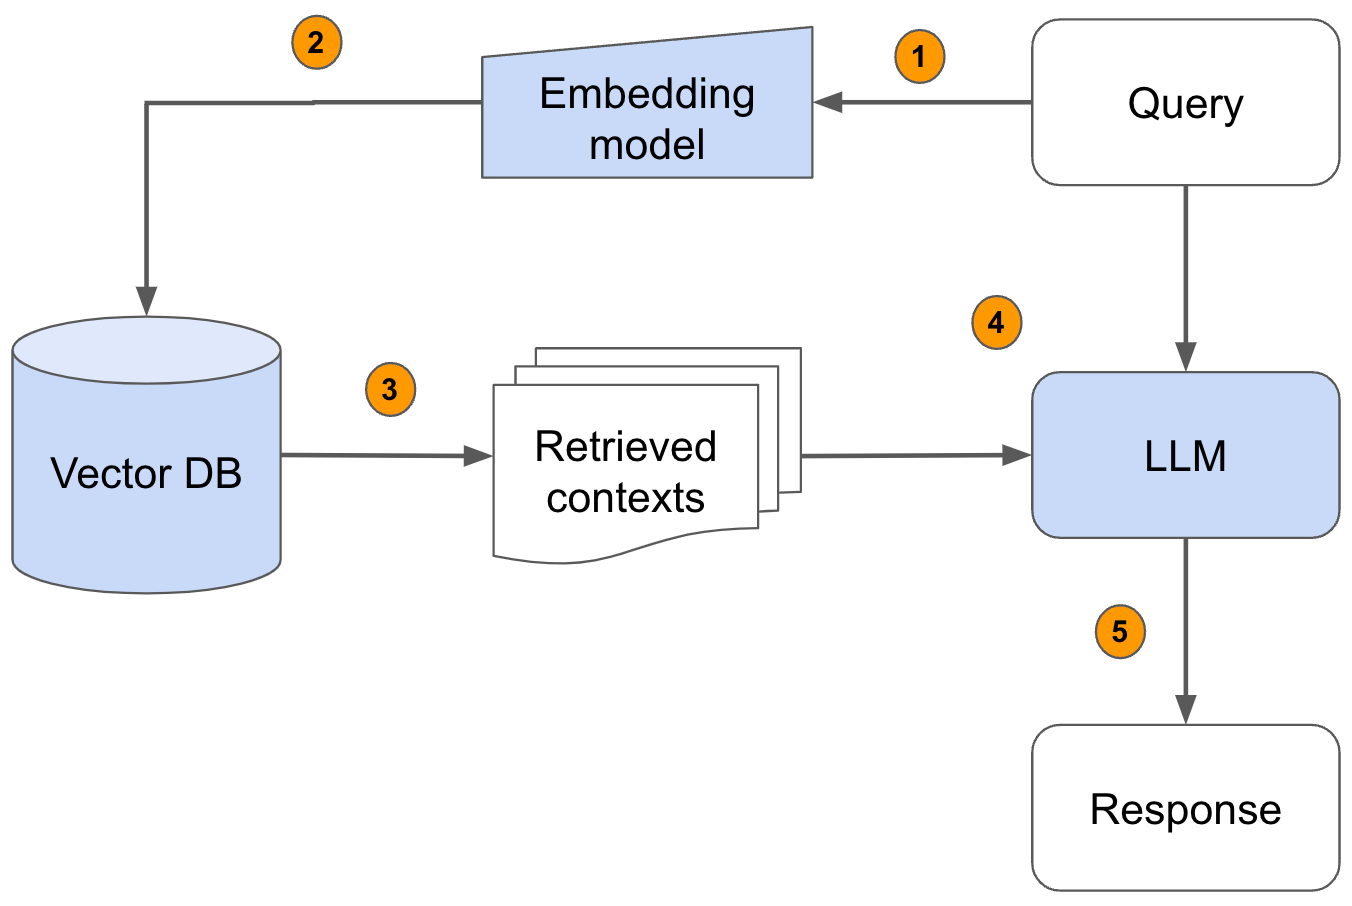

ZERO SHORT PROMPTING (INSTRUCTION WITHOUT EXAMPLE)

In [422]:
system_prompt=(
    "You are an assistant for question-answering tasks."
    "Use the following pieces of retrieved context to answer the questions."
    "If you don't know the answer, say that you don't know."
    "Use three sentences maximum and keep the answer concise."
    "\n\n"
    "{context}"
)

In [423]:
chat_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",system_prompt),
        ("human","{input}"),
    ]
)

In [424]:
question_answer_chain=create_stuff_documents_chain(model,chat_prompt)

In [425]:
rag_chain=create_retrieval_chain(retriever,question_answer_chain)

In [426]:
response = rag_chain.invoke({"input" : "What is Building agents with LLM?"})

In [427]:
response["answer"]

"The provided text only mentions challenges in building LLM-centered agents, not what building such agents entails.  Therefore, I don't know what building agents with LLMs is.  More information is needed."

In [428]:
from langchain.chains import create_history_aware_retriever


In [429]:
retriever_prompt=(
    "Given a chat history and the latest user question which might refrence context in the chat history."
    "formulate a standalone question which can be understood without the chat history."
    "Do NOT answer the question, just reformulate it if needed and otherwise return it as is."
)

In [430]:
contextualize_q_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",retriever_prompt),
        MessagesPlaceholder(variable_name="chat_history"),
        ("human","{input}"),
    ]
)

In [431]:
history_aware_retriver=create_history_aware_retriever(model,retriever,contextualize_q_prompt)

In [432]:
from langchain.chains.combine_documents import create_stuff_documents_chain

In [433]:
qa_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",system_prompt),
        MessagesPlaceholder("chat_history"),
        ("human","{input}"),
    ]
)

In [434]:
question_answer_chain=create_stuff_documents_chain(model,qa_prompt)

In [435]:
rag_chain=create_retrieval_chain(history_aware_retriver,question_answer_chain)

In [436]:
from langchain_core.messages import HumanMessage,AIMessage

In [437]:
chat_history=[]

In [438]:
question1="what is JAVA?"

In [439]:
message1=rag_chain.invoke({"input":question1,"chat_history":chat_history})

In [440]:
message1["answer"]

'The provided text only mentions "pytest" and "dataclasses," which are Python-related terms.  It does not contain information about Java.  Therefore, I don\'t know what Java is.'

In [441]:
chat_history.extend(
    [
        HumanMessage(content=question1),
        AIMessage(content=message1["answer"]),
    ]
)

In [442]:
chat_history

[HumanMessage(content='what is JAVA?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='The provided text only mentions "pytest" and "dataclasses," which are Python-related terms.  It does not contain information about Java.  Therefore, I don\'t know what Java is.', additional_kwargs={}, response_metadata={})]

In [443]:
second_question="Is this programming language?"
message2=rag_chain.invoke({"input":second_question,"chat_history":chat_history})
print(message2["answer"])

Yes, Java is a programming language.
